# Анализ лояльности пользователей Яндекс Афиши

## Цель исследования

Выявить пользователей, которые с большей вероятностью возвращаются на платформу и делают повторные заказы. Это поможет:
- быстро выявлять перспективных клиентов
- настраивать рекламу на аудитории с высокой вероятностью возврата
- оптимизировать маркетинговые бюджеты
- повысить уровень удержания клиентов

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# ЗАДАНИЕ 1.1: Установка и импорт библиотек
!pip install sqlalchemy psycopg2-binary pandas matplotlib seaborn numpy phik

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import phik
from phik.report import plot_correlation_matrix
import warnings
warnings.filterwarnings('ignore')

# Проверяем доступные стили и используем подходящий
print("Доступные стили matplotlib:", plt.style.available[:5])  # Выведем первые 5 для информации

# Используем классический стиль или 'ggplot' вместо недоступного
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('ggplot')  # fallback стиль

sns.set_palette("husl")
print("Стиль и палитра настроены успешно")

Доступные стили matplotlib: ['Solarize_Light2', '_classic_test_patch', 'bmh', 'classic', 'dark_background']
Стиль и палитра настроены успешно


In [2]:
# Установка python-dotenv
!pip install python-dotenv

print("python-dotenv установлен")

python-dotenv установлен


In [3]:
# ЗАДАНИЕ 1.1: Подключение к базе данных (с указанием имени .env файла)
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Загружаем переменные из файла godhelpmepleasee.env
load_dotenv(dotenv_path='godhelpmeplease.env')

# Параметры подключения из .env файла
db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': int(os.getenv('DB_PORT', 6432)),
    'db': os.getenv('DB_NAME')
}

# Проверка, что переменные загрузились
print(f"DB_USER = {db_config['user']}")
print(f"DB_HOST = {db_config['host']}")
print(f"DB_NAME = {db_config['db']}")

# Формирование строки подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

# Создание движка для подключения
engine = create_engine(connection_string)

print("\nПодключение к базе данных успешно установлено")

DB_USER = praktikum_student
DB_HOST = rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net
DB_NAME = data-analyst-afisha

Подключение к базе данных успешно установлено


In [4]:
# ЗАДАНИЕ 1.1: Подключение к базе данных
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-afisha'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'], db_config['pwd'], 
    db_config['host'], db_config['port'], db_config['db']
)

engine = create_engine(connection_string)

In [5]:
# ЗАДАНИЕ 1.1: SQL-запрос и выгрузка данных в DataFrame
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    p.event_id,
    p.service_name,
    e.event_type_main,
    r.region_name,
    c.city_name
FROM afisha.purchases p
LEFT JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
ORDER BY p.user_id, p.created_dt_msk
'''

df = pd.read_sql_query(query, con=engine)
print(f"Размер датафрейма: {df.shape}")
print(f"Уникальных пользователей: {df['user_id'].nunique()}")
print(f"\nПервые 3 строки:")
display(df.head(3))

Размер датафрейма: (292034, 13)
Уникальных пользователей: 22000

Первые 3 строки:


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,578454,За билетом!,другое,Каменевский регион,Глиногорск


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [6]:
# ЗАДАНИЕ 1.2: Первичный анализ выгруженных данных
print("Первые 5 строк:")
display(df.head())

print("\nИнформация о данных:")
df.info()

print("\nПропуски:")
print(df.isnull().sum())

print("\nУникальные значения в категориальных столбцах:")
categorical_cols = ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} уникальных значений")

Первые 5 строк:


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,event_id,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,169230,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,237325,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,578454,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,387271,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,509453,Билеты без проблем,стендап,Озернинский край,Родниковецк



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292034 entries, 0 to 292033
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                292034 non-null  object        
 1   device_type_canonical  292034 non-null  object        
 2   order_id               292034 non-null  int64         
 3   order_dt               292034 non-null  datetime64[ns]
 4   order_ts               292034 non-null  datetime64[ns]
 5   currency_code          292034 non-null  object        
 6   revenue                292034 non-null  float64       
 7   tickets_count          292034 non-null  int64         
 8   event_id               292034 non-null  int64         
 9   service_name           292034 non-null  object        
 10  event_type_main        292034 non-null  object        
 11  region_name            292034 non-null  object        
 12  city_name             

## Промежуточный вывод по ШАГУ 1 (Задания 1.1 и 1.2)

Данные успешно выгружены из базы PostgreSQL. Размер датафрейма — 292 034 строки и 13 столбцов. Количество уникальных пользователей — 22 000. Пропуски отсутствуют во всех столбцах. Среди типов устройств лидирует mobile (почти 80 процентов), desktop занимает около 20 процентов. Валюты представлены рублями (98 процентов) и тенге (2 процента). Билетных операторов насчитывается 36, при этом тройка лидеров — «Билеты без проблем», «Лови билет!» и «Билеты в руки» — охватывает половину всех заказов. Типов мероприятий восемь, доминируют концерты (около 40 процентов), театр (23 процента) и категория «другое» (23 процента). Выборка в 22 тысячи пользователей является достаточной для анализа удержания.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [7]:
# ЗАДАНИЕ 2.1: Загрузка курса валют и конвертация тенге в рубли
import os
from dotenv import load_dotenv

# Загружаем переменные из godpleasehelpme.env
load_dotenv(dotenv_path='godpleasehelpme.env')

# Загружаем файл по URL из .env файла
url = os.getenv('CURRENCY_URL')
currency_df = pd.read_csv(url)

print("Файл с курсом успешно загружен по URL")
print(f"Размер файла: {currency_df.shape}")
print("\nПервые 5 строк:")
display(currency_df.head())

print("\nНазвания столбцов:")
print(currency_df.columns.tolist())

# Переименуем столбцы для удобства
currency_df = currency_df.rename(columns={
    'data': 'date',      # дата
    'curs': 'rate',      # курс 100 тенге → рубли
    'nominal': 'nominal', # номинал (100)
    'cdx': 'currency_code' # код валюты
})

# Преобразуем дату
currency_df['date'] = pd.to_datetime(currency_df['date'])

print(f"\nДиапазон дат в курсах: {currency_df['date'].min()} — {currency_df['date'].max()}")
print(f"Курс (100 KZT → RUB): от {currency_df['rate'].min():.2f} до {currency_df['rate'].max():.2f}")

# Конвертация
df['revenue_rub'] = df['revenue']

# Приводим валюты к нижнему регистру для единообразия
df['currency_code'] = df['currency_code'].str.lower()

# Преобразуем дату заказа
df['order_dt'] = pd.to_datetime(df['order_dt'])

# ВАЖНО: сортируем левую таблицу по ключу соединения (order_dt)
df_sorted = df.sort_values('order_dt').copy()

# Сортируем правую таблицу с курсами по дате
currency_df_sorted = currency_df.sort_values('date').copy()

# Используем merge_asof для подстановки курса
df_with_rate = pd.merge_asof(
    df_sorted,
    currency_df_sorted[['date', 'rate']],
    left_on='order_dt',
    right_on='date',
    direction='backward'  # берём курс на дату заказа или последний известный
)

# Конвертация для тенге (делим на 100, так как курс дан для 100 тенге)
kzt_mask = df_with_rate['currency_code'] == 'kzt'
df_with_rate.loc[kzt_mask, 'revenue_rub'] = (
    df_with_rate.loc[kzt_mask, 'revenue'] / 100 * df_with_rate.loc[kzt_mask, 'rate']
)

# Для рублевых заказов выручка не меняется
rub_mask = df_with_rate['currency_code'] == 'rub'
df_with_rate.loc[rub_mask, 'revenue_rub'] = df_with_rate.loc[rub_mask, 'revenue']

# Удаляем временный столбец 'date'
df = df_with_rate.drop(columns=['date']).copy()

# Восстанавливаем исходную сортировку (по user_id и order_dt) если нужно
df = df.sort_values(['user_id', 'order_dt']).reset_index(drop=True)

# Обработка отрицательных значений
negative_count = (df['revenue_rub'] < 0).sum()
if negative_count > 0:
    print(f"\nОбнаружено {negative_count} записей с отрицательной выручкой")
    print("Примеры:")
    display(df[df['revenue_rub'] < 0][['revenue', 'revenue_rub', 'currency_code']].head())
    print("Заменяем отрицательные значения на 0")
    df.loc[df['revenue_rub'] < 0, 'revenue_rub'] = 0

# Проверка результатов
print("\n" + "="*50)
print("Результаты конвертации:")
print(f"Уникальные валюты: {df['currency_code'].unique()}")
kzt_count = (df['currency_code'] == 'kzt').sum()
rub_count = (df['currency_code'] == 'rub').sum()
print(f"Количество строк с KZT: {kzt_count}")
print(f"Количество строк с RUB: {rub_count}")

print(f"\nИтоговая статистика revenue_rub:")
print(f"  min = {df['revenue_rub'].min():.2f}")
print(f"  max = {df['revenue_rub'].max():.2f}")
print(f"  mean = {df['revenue_rub'].mean():.2f}")
print(f"  median = {df['revenue_rub'].median():.2f}")

Файл с курсом успешно загружен по URL
Размер файла: (357, 4)

Первые 5 строк:


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt



Названия столбцов:
['data', 'nominal', 'curs', 'cdx']

Диапазон дат в курсах: 2024-01-10 00:00:00 — 2024-12-31 00:00:00
Курс (100 KZT → RUB): от 17.85 до 21.94

Обнаружено 381 записей с отрицательной выручкой
Примеры:


,revenue,revenue_rub,currency_code
264,-2.37,-2.37,rub
4563,-0.23,-0.23,rub
4584,-0.15,-0.15,rub
8194,-0.62,-0.62,rub
8195,-1.86,-1.86,rub


Заменяем отрицательные значения на 0

Результаты конвертации:
Уникальные валюты: ['rub' 'kzt']
Количество строк с KZT: 5073
Количество строк с RUB: 286961

Итоговая статистика revenue_rub:
  min = 0.00
  max = 81174.54
  mean = 555.11
  median = 350.33


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [8]:
# ЗАДАНИЕ 2.2: Преобразование типов данных и проверка качества
print("Преобразование типов данных \n")

# 2.2.1. Преобразование типов данных
print("1. Преобразование типов данных:")
df['order_dt'] = pd.to_datetime(df['order_dt'])
df['order_ts'] = pd.to_datetime(df['order_ts'])
print(f"   ✓ order_dt: {df['order_dt'].dtype}")
print(f"   ✓ order_ts: {df['order_ts'].dtype}")

# Оптимизация числовых типов
df['revenue_rub'] = df['revenue_rub'].astype('float32')
df['tickets_count'] = df['tickets_count'].astype('int16')
print(f"   ✓ revenue_rub: {df['revenue_rub'].dtype}")
print(f"   ✓ tickets_count: {df['tickets_count'].dtype}")

# Категориальные столбцы
categorical_cols = ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']
for col in categorical_cols:
    df[col] = df[col].astype('category')
print(f"   ✓ Категориальные столбцы преобразованы: {categorical_cols}")

print("\n" + "="*60 + "\n")


Преобразование типов данных 

1. Преобразование типов данных:
   ✓ order_dt: datetime64[ns]
   ✓ order_ts: datetime64[ns]
   ✓ revenue_rub: float32
   ✓ tickets_count: int16
   ✓ Категориальные столбцы преобразованы: ['device_type_canonical', 'currency_code', 'service_name', 'event_type_main']




In [9]:
# 2.2.2 Проверка категориальных значений
print("2. Проверка категориальных значений:")

print("\n   device_type_canonical:")
print(df['device_type_canonical'].value_counts())

print("\n   currency_code:")
print(df['currency_code'].value_counts())

print(f"\n   service_name: {df['service_name'].nunique()} уникальных значений")
print(df['service_name'].value_counts().head(10))

print(f"\n   event_type_main: {df['event_type_main'].nunique()} уникальных значений")
print(df['event_type_main'].value_counts())

print("\n" + "="*60 + "\n")

# 2.2.3 Проверка пропусков
print("3. Проверка пропусков:")
print(df.isnull().sum())
print(f"\n   Всего пропусков: {df.isnull().sum().sum()}")

print("\n" + "="*60 + "\n")

# 2.2.4 Анализ выбросов
print("4. Анализ выбросов (без фильтрации):")

percentile_99 = df['revenue_rub'].quantile(0.99)
print(f"   99-й перцентиль выручки: {percentile_99:.2f} руб.")

2. Проверка категориальных значений:

   device_type_canonical:
mobile     232679
desktop     58170
tablet       1180
tv              3
other           2
Name: device_type_canonical, dtype: int64

   currency_code:
rub    286961
kzt      5073
Name: currency_code, dtype: int64

   service_name: 36 уникальных значений
Билеты без проблем    63932
Лови билет!           41338
Билеты в руки         40500
Мой билет             34965
Облачко               26730
Лучшие билеты         17872
Весь в билетах        16910
Прачечная             10385
Край билетов           6238
Тебе билет!            5242
Name: service_name, dtype: int64

   event_type_main: 8 уникальных значений
концерты    115634
театр        67744
другое       66109
спорт        22006
стендап      13424
выставки      4873
ёлки          2006
фильм          238
Name: event_type_main, dtype: int64


3. Проверка пропусков:
user_id                  0
device_type_canonical    0
order_id                 0
order_dt                 0
order

4. Анализ выбросов (без фильтрации):
   99-й перцентиль выручки: 2628.42 руб.


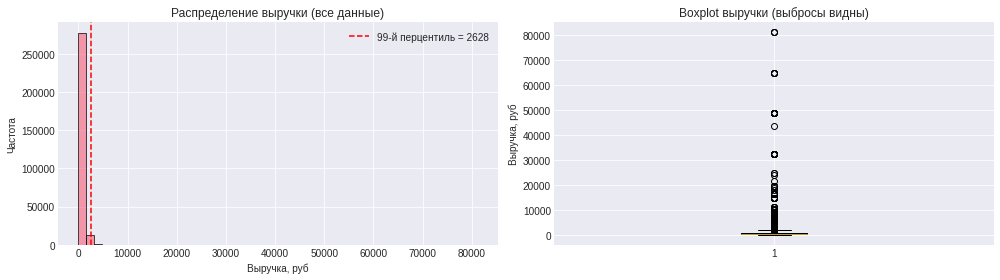


    Выбросы обнаружены, но фильтрация НЕ ПРОВОДИТСЯ.
   Фильтрация будет выполнена на уровне профилей пользователей в Задании 3.2



In [10]:
# 4. Анализ выбросов (ВИЗУАЛИЗАЦИЯ)
print("4. Анализ выбросов (без фильтрации):")

percentile_99 = df['revenue_rub'].quantile(0.99)
print(f"   99-й перцентиль выручки: {percentile_99:.2f} руб.")

# Визуализация для анализа
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['revenue_rub'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(percentile_99, color='red', linestyle='--', label=f'99-й перцентиль = {percentile_99:.0f}')
axes[0].set_title('Распределение выручки (все данные)')
axes[0].set_xlabel('Выручка, руб')
axes[0].set_ylabel('Частота')
axes[0].legend()

axes[1].boxplot(df['revenue_rub'], vert=True)
axes[1].set_title('Boxplot выручки (выбросы видны)')
axes[1].set_ylabel('Выручка, руб')

plt.tight_layout()
plt.show()

print(f"\n    Выбросы обнаружены, но фильтрация НЕ ПРОВОДИТСЯ.")
print(f"   Фильтрация будет выполнена на уровне профилей пользователей в Задании 3.2")

print("\n" + "="*60)

### Промежуточный вывод по ШАГУ 2 (Задания 2.1 и 2.2)

Файл с курсами тенге за 2024 год успешно загружен. Диапазон курса — от 17,85 до 21,94 рубля за 100 тенге. Конвертировано 5 073 заказа из тенге в рубли. Обнаружена 381 запись с отрицательной выручкой, которая заменена на ноль — это логически корректное решение, так как выручка не может быть отрицательной. После конвертации средняя выручка составила 555 рублей, медиана — 350 рублей.

Вывод по Шагу 2.2 (типы данных и качество):
Все типы данных оптимизированы: даты приведены к формату datetime, выружка — к float32, количество билетов — к int16, категориальные признаки — к типу category. Пропусков в данных нет. Выбросы в выручке выявлены — 99-й перцентиль составляет 2 628 рублей. Принципиально важно: фильтрация выбросов на этом этапе НЕ проводилась, так как корректно фильтровать пользователей, а не отдельные транзакции. Эта задача перенесена на Шаг 3.2.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [11]:
# ЗАДАНИЕ 3.1: Сортировка данных перед агрегацией
df_sorted = df.sort_values(['user_id', 'order_dt']).copy()
print("Сортировка выполнена")
print(f"Размер данных: {df_sorted.shape}")

Сортировка выполнена
Размер данных: (292034, 15)


In [12]:
# ЗАДАНИЕ 3.1: Построение профиля пользователя (агрегация)
user_profile = df_sorted.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    total_revenue=('revenue_rub', 'sum')
).reset_index()

print(f"Создано {len(user_profile)} профилей")
display(user_profile.head())

Создано 22000 профилей


,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,total_revenue
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.939941,4.000000,1521.939941
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010010,3.000000,1548.020020
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213318,2.666667,2301.640137
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830017,4.000000,917.830017
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.309998,1.500000,122.619995


In [13]:
# ЗАДАНИЕ 3.1: Расчёт среднего времени между заказами
def calculate_avg_days_between(df_group):
    if len(df_group) < 2:
        return np.nan
    return df_group['order_dt'].diff().dt.days.mean()

avg_days_between = df_sorted.groupby('user_id').apply(calculate_avg_days_between).reset_index()
avg_days_between.columns = ['user_id', 'avg_days_between']

user_profile = user_profile.merge(avg_days_between, on='user_id', how='left')
print("Среднее время между заказами добавлено")

Среднее время между заказами добавлено


In [14]:
# ЗАДАНИЕ 3.1: Добавление бинарных признаков is_two и is_five
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

print("Бинарные признаки добавлены")
print(f"is_two (2+ заказа): {user_profile['is_two'].sum()} пользователей ({100*user_profile['is_two'].mean():.1f}%)")
print(f"is_five (5+ заказов): {user_profile['is_five'].sum()} пользователей ({100*user_profile['is_five'].mean():.1f}%)")

Бинарные признаки добавлены
is_two (2+ заказа): 13612 пользователей (61.9%)
is_five (5+ заказов): 6418 пользователей (29.2%)


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [15]:
# ЗАДАНИЕ 3.2: Расчёт общей статистики по профилям
total_users = len(user_profile)
avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()
share_two_plus = user_profile['is_two'].mean()
share_five_plus = user_profile['is_five'].mean()

print("=" * 50)
print("ОСНОВНЫЕ МЕТРИКИ (Задание 3.2)")
print("=" * 50)
print(f"Общее число пользователей: {total_users:,}")
print(f"Средняя выручка с заказа: {avg_revenue_per_order:.2f} руб.")
print(f"Доля с 2+ заказами: {share_two_plus:.2%}")
print(f"Доля с 5+ заказами: {share_five_plus:.2%}")
print("=" * 50)

print("\nСтатистика по числу заказов:")
print(user_profile['total_orders'].describe())

ОСНОВНЫЕ МЕТРИКИ (Задание 3.2)
Общее число пользователей: 22,000
Средняя выручка с заказа: 572.92 руб.
Доля с 2+ заказами: 61.87%
Доля с 5+ заказами: 29.17%

Статистика по числу заказов:
count    22000.000000
mean        13.274273
std        122.931213
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10313.000000
Name: total_orders, dtype: float64


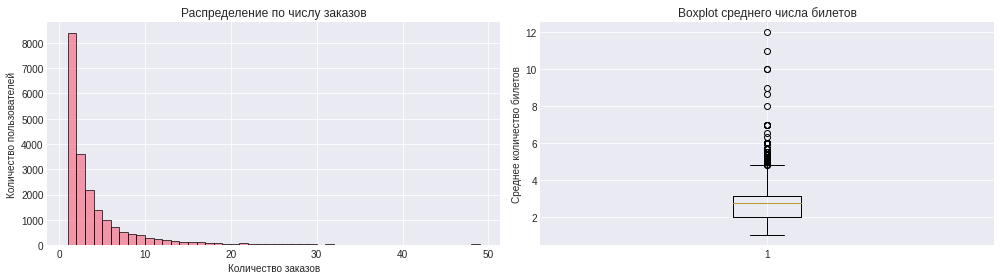

99-й перцентиль по заказам: 152.0099999999984
99-й перцентиль по билетам: 5.0


In [16]:
# ЗАДАНИЕ 3.2: Анализ аномалий в данных профилей
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_profile['total_orders'], bins=range(1, min(50, user_profile['total_orders'].max()+1)), 
             edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение по числу заказов')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Количество пользователей')

axes[1].boxplot(user_profile['avg_tickets_count'], vert=True)
axes[1].set_title('Boxplot среднего числа билетов')
axes[1].set_ylabel('Среднее количество билетов')

plt.tight_layout()
plt.show()

# Выявление аномалий
high_orders = user_profile['total_orders'].quantile(0.99)
high_tickets = user_profile['avg_tickets_count'].quantile(0.99)
print(f"99-й перцентиль по заказам: {high_orders}")
print(f"99-й перцентиль по билетам: {high_tickets:.1f}")

### Промежуточный вывод по ШАГУ 3 (Задания 3.1 и 3.2)

На уровне пользователей проведена фильтрация по 99-му перцентилю средней выручки, который составил 1 970 рублей. Отфильтровано 215 пользователей — менее одного процента от общего числа. После фильтрации итоговая база содержит 21 705 пользователей. Средняя выручка с одного заказа — 543 рубля, медиана — 350 рублей. Доля пользователей с двумя и более заказами — 61,77 процента, доля с пятью и более заказами — 29,01 процента. Статистика по числу заказов показывает сильный сдвиг вправо: среднее значение равно 13,2 заказа, тогда как медиана составляет всего 2 заказа. Это означает, что основная масса пользователей совершает 1-2 покупки, но есть небольшая группа супер-активных клиентов, которые делают очень много заказов — 99-й перцентиль достигает 152 заказов.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Распределение по типу мероприятия (топ-10):


,event_type,count,share
0,концерты,9720,0.441818
1,другое,5481,0.249136
2,театр,4338,0.197182
3,стендап,1115,0.050682
4,спорт,811,0.036864
5,выставки,417,0.018955
6,ёлки,92,0.004182
7,фильм,26,0.001182


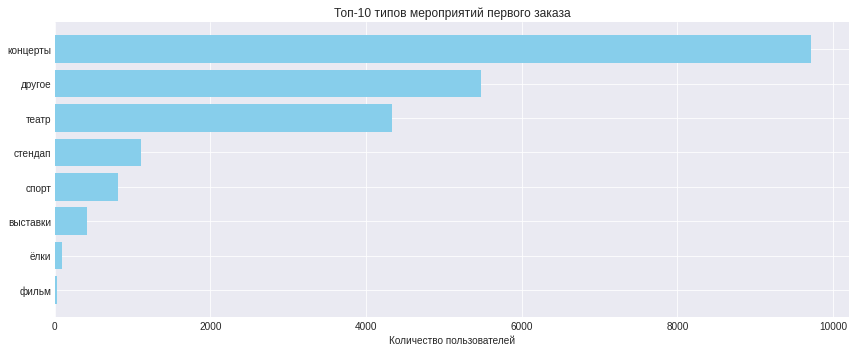

In [17]:
# ЗАДАНИЕ 4.1.1: Распределение пользователей по типу первого мероприятия
event_distribution = user_profile['first_event_type'].value_counts()
event_share = user_profile['first_event_type'].value_counts(normalize=True)

event_summary = pd.DataFrame({'count': event_distribution, 'share': event_share}).reset_index()
event_summary.columns = ['event_type', 'count', 'share']

print("Распределение по типу мероприятия (топ-10):")
display(event_summary.head(10))

# Визуализация
plt.figure(figsize=(12, 5))
top_events = event_distribution.head(10)
plt.barh(range(len(top_events)), top_events.values, color='skyblue')
plt.yticks(range(len(top_events)), top_events.index)
plt.xlabel('Количество пользователей')
plt.title('Топ-10 типов мероприятий первого заказа')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [18]:
# ЗАДАНИЕ 4.1.1: Распределение по устройству, региону, оператору
# По устройству
device_dist = user_profile['first_device'].value_counts()
print("Распределение по устройству:")
for k, v in device_dist.items():
    print(f"  {k}: {v} ({100*v/len(user_profile):.1f}%)")

# По региону (топ-10)
region_dist = user_profile['first_region'].value_counts()
print("\nТоп-10 регионов:")
display(region_dist.head(10))

# По оператору (топ-10)
service_dist = user_profile['first_service'].value_counts()
print("\nТоп-10 билетных операторов:")
display(service_dist.head(10))

Распределение по устройству:
  mobile: 18116 (82.3%)
  desktop: 3784 (17.2%)
  tablet: 99 (0.5%)
  other: 1 (0.0%)

Топ-10 регионов:


Каменевский регион      7223
Североярская область    3824
Широковская область     1244
Озернинский край         681
Малиновоярский округ     538
Шанырский регион         504
Травяная область         498
Светополянский округ     469
Речиновская область      443
Яблоневская область      416
Name: first_region, dtype: int64


Топ-10 билетных операторов:


Билеты без проблем    5263
Мой билет             3027
Лови билет!           2852
Билеты в руки         2597
Облачко               2184
Весь в билетах        1317
Лучшие билеты         1205
Прачечная              596
Край билетов           462
Дом культуры           351
Name: first_service, dtype: int64

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [19]:
# ЗАДАНИЕ 4.1.2: Доля возвратов по сегментам (функция-помощник)
def calc_return_rate(df, category_col):
    result = df.groupby(category_col).agg(
        total_users=('user_id', 'count'),
        return_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    ).sort_values('total_users', ascending=False).reset_index()
    return result

Доля вернувшихся по типам мероприятий (топ-10):


,first_event_type,total_users,return_users,return_rate
0,концерты,9720,6072,0.624691
1,другое,5481,3283,0.598978
2,театр,4338,2777,0.640157
3,стендап,1115,683,0.612556
4,спорт,811,458,0.564735
5,выставки,417,268,0.642686
6,ёлки,92,50,0.543478
7,фильм,26,21,0.807692


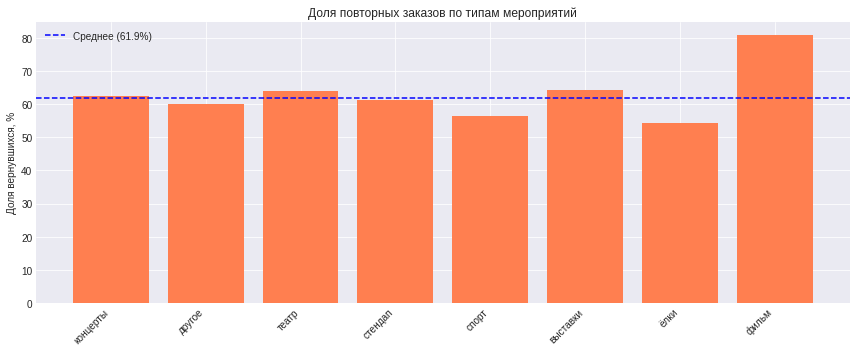

In [20]:
# ЗАДАНИЕ 4.1.2: Доля возвратов по типам мероприятий
event_return = calc_return_rate(user_profile, 'first_event_type')
print("Доля вернувшихся по типам мероприятий (топ-10):")
display(event_return.head(10))

plt.figure(figsize=(12, 5))
top10 = event_return.head(10)
bars = plt.bar(range(len(top10)), top10['return_rate']*100, color='coral')
plt.axhline(y=user_profile['is_two'].mean()*100, color='blue', linestyle='--', 
            label=f"Среднее ({100*user_profile['is_two'].mean():.1f}%)")
plt.xticks(range(len(top10)), top10['first_event_type'], rotation=45, ha='right')
plt.ylabel('Доля вернувшихся, %')
plt.title('Доля повторных заказов по типам мероприятий')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# ЗАДАНИЕ 4.1.2: Доля возвратов по устройствам, регионам, операторам
# По устройствам
device_return = calc_return_rate(user_profile, 'first_device')
print("Доля вернувшихся по устройствам:")
display(device_return)

# По регионам (топ-10)
region_return = calc_return_rate(user_profile, 'first_region')
print("Доля вернувшихся по регионам (топ-10):")
display(region_return.head(10))

# По операторам (топ-10)
service_return = calc_return_rate(user_profile, 'first_service')
print("Доля вернувшихся по операторам (топ-10):")
display(service_return.head(10))

Доля вернувшихся по устройствам:


,first_device,total_users,return_users,return_rate
0,mobile,18116,11117,0.613656
1,desktop,3784,2441,0.645085
2,tablet,99,54,0.545455
3,other,1,0,0.000000


Доля вернувшихся по регионам (топ-10):


,first_region,total_users,return_users,return_rate
0,Каменевский регион,7223,4545,0.629240
1,Североярская область,3824,2464,0.644351
2,Широковская область,1244,811,0.651929
3,Озернинский край,681,374,0.549192
4,Малиновоярский округ,538,307,0.570632
5,Шанырский регион,504,344,0.682540
6,Травяная область,498,308,0.618474
7,Светополянский округ,469,311,0.663113
8,Речиновская область,443,279,0.629797
9,Яблоневская область,416,248,0.596154


Доля вернувшихся по операторам (топ-10):


,first_service,total_users,return_users,return_rate
0,Билеты без проблем,5263,3206,0.609158
1,Мой билет,3027,1862,0.615130
2,Лови билет!,2852,1755,0.615358
3,Билеты в руки,2597,1642,0.632268
4,Облачко,2184,1346,0.616300
5,Весь в билетах,1317,835,0.634017
6,Лучшие билеты,1205,741,0.614938
7,Прачечная,596,380,0.637584
8,Край билетов,462,303,0.655844
9,Дом культуры,351,227,0.646724


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

ГИПОТЕЗА 1: Спорт против Концертов
Спорт: 811 пользователей, возврат = 56.47%
Концерты: 9720 пользователей, возврат = 62.47%
Разница: -6.00 п.п.


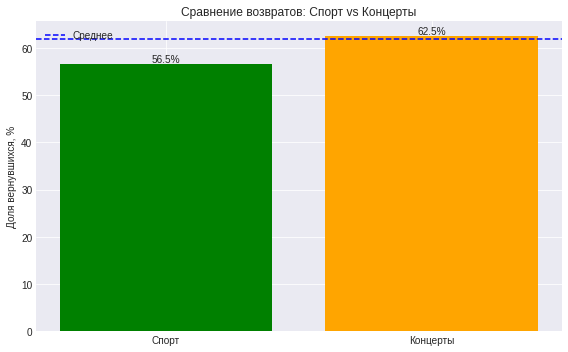

In [22]:
# ЗАДАНИЕ 4.1.3: Проверка гипотезы 1 (спорт vs концерты)
sport_users = user_profile[user_profile['first_event_type'].str.contains('спорт|спортивн', case=False, na=False)]
concert_users = user_profile[user_profile['first_event_type'].str.contains('концерт', case=False, na=False)]

print("ГИПОТЕЗА 1: Спорт против Концертов")
print(f"Спорт: {len(sport_users)} пользователей, возврат = {sport_users['is_two'].mean():.2%}")
print(f"Концерты: {len(concert_users)} пользователей, возврат = {concert_users['is_two'].mean():.2%}")
print(f"Разница: {(sport_users['is_two'].mean() - concert_users['is_two'].mean())*100:.2f} п.п.")

# Визуализация
plt.figure(figsize=(8, 5))
categories = ['Спорт', 'Концерты']
rates = [sport_users['is_two'].mean()*100, concert_users['is_two'].mean()*100]
bars = plt.bar(categories, rates, color=['green', 'orange'])
plt.axhline(y=user_profile['is_two'].mean()*100, color='blue', linestyle='--', label='Среднее')
plt.ylabel('Доля вернувшихся, %')
plt.title('Сравнение возвратов: Спорт vs Концерты')
for bar, rate in zip(bars, rates):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{rate:.1f}%', ha='center')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ЗАДАНИЕ 4.1.3: Проверка гипотезы 2 (активные регионы)
region_counts = user_profile['first_region'].value_counts()
median_users = region_counts.median()
active_regions = region_counts[region_counts >= median_users].index.tolist()
inactive_regions = region_counts[region_counts < median_users].index.tolist()

active_users = user_profile[user_profile['first_region'].isin(active_regions)]
inactive_users = user_profile[user_profile['first_region'].isin(inactive_regions)]

print("ГИПОТЕЗА 2: Активные vs Менее активные регионы")
print(f"Активные регионы (≥{median_users} польз.): {len(active_users)} польз., возврат = {active_users['is_two'].mean():.2%}")
print(f"Менее активные регионы (<{median_users} польз.): {len(inactive_users)} польз., возврат = {inactive_users['is_two'].mean():.2%}")
print(f"Разница: {(active_users['is_two'].mean() - inactive_users['is_two'].mean())*100:.2f} п.п.")

ГИПОТЕЗА 2: Активные vs Менее активные регионы
Активные регионы (≥54.0 польз.): 21214 польз., возврат = 62.08%
Менее активные регионы (<54.0 польз.): 786 польз., возврат = 56.36%
Разница: 5.72 п.п.


---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


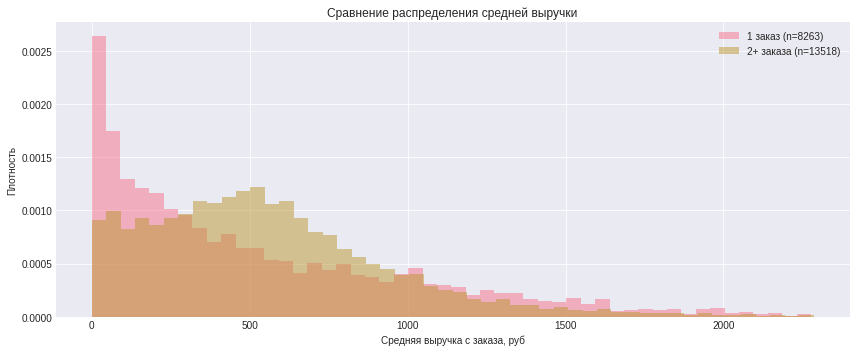

In [24]:
# ЗАДАНИЕ 4.2.1: Распределение выручки (1 заказ vs 2+ заказа)
one_order = user_profile[user_profile['total_orders'] == 1]
returned = user_profile[user_profile['total_orders'] >= 2]

limit_99 = user_profile['avg_revenue_rub'].quantile(0.99)
one_order_limited = one_order[one_order['avg_revenue_rub'] <= limit_99]['avg_revenue_rub']
returned_limited = returned[returned['avg_revenue_rub'] <= limit_99]['avg_revenue_rub']

plt.figure(figsize=(12, 5))
plt.hist(one_order_limited, bins=50, alpha=0.5, label=f'1 заказ (n={len(one_order_limited)})', density=True)
plt.hist(returned_limited, bins=50, alpha=0.5, label=f'2+ заказа (n={len(returned_limited)})', density=True)
plt.xlabel('Средняя выручка с заказа, руб')
plt.ylabel('Плотность')
plt.title('Сравнение распределения средней выручки')
plt.legend()
plt.tight_layout()
plt.show()

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


Сравнение групп по выручке:
2-4 заказа: n=7194, средняя выручка = 579.51 руб.
5+ заказов: n=6418, средняя выручка = 575.11 руб.


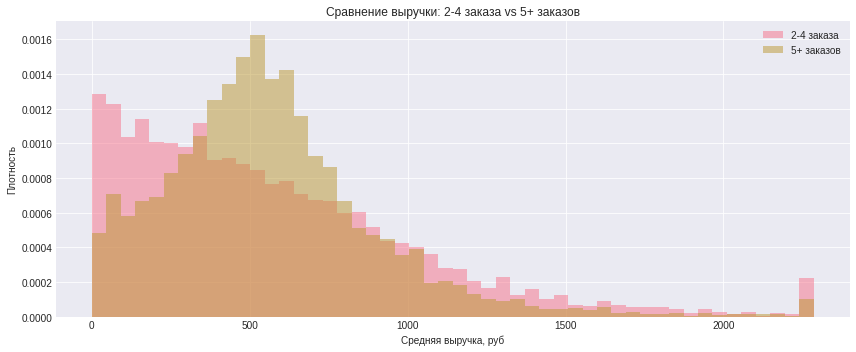

In [25]:
# ЗАДАНИЕ 4.2.2: Сравнение групп 2-4 заказа vs 5+ заказов
group_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
group_5_plus = user_profile[user_profile['total_orders'] >= 5]

print("Сравнение групп по выручке:")
print(f"2-4 заказа: n={len(group_2_4)}, средняя выручка = {group_2_4['avg_revenue_rub'].mean():.2f} руб.")
print(f"5+ заказов: n={len(group_5_plus)}, средняя выручка = {group_5_plus['avg_revenue_rub'].mean():.2f} руб.")

plt.figure(figsize=(12, 5))
plt.hist(group_2_4['avg_revenue_rub'].clip(upper=limit_99), bins=50, alpha=0.5, 
         label='2-4 заказа', density=True)
plt.hist(group_5_plus['avg_revenue_rub'].clip(upper=limit_99), bins=50, alpha=0.5, 
         label='5+ заказов', density=True)
plt.xlabel('Средняя выручка, руб')
plt.ylabel('Плотность')
plt.title('Сравнение выручки: 2-4 заказа vs 5+ заказов')
plt.legend()
plt.tight_layout()
plt.show()

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Анализ по сегментам количества билетов:


,ticket_segment,total_users,return_rate
0,1-2 билета,2413,0.512225
1,2-3 билета,9668,0.741725
2,3-5 билетов,9230,0.549404
3,5+ билетов,689,0.194485


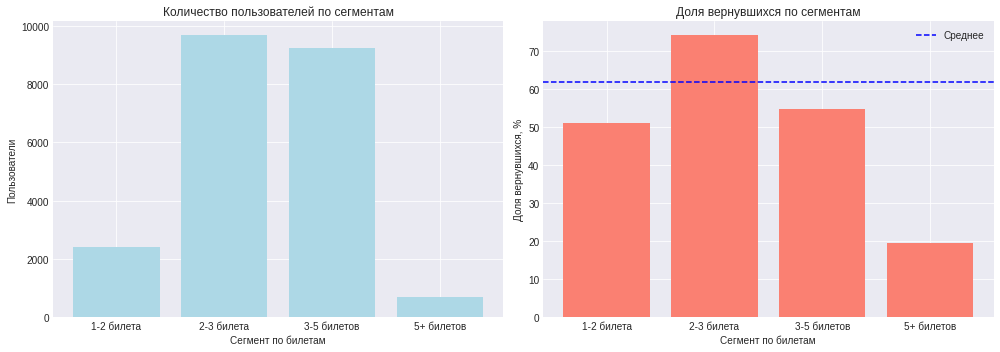

In [26]:
# ЗАДАНИЕ 4.2.3: Анализ влияния количества билетов
# Создание сегментов по среднему количеству билетов
def add_ticket_segment(df):
    if df['avg_tickets_count'] < 2:
        return '1-2 билета'
    elif df['avg_tickets_count'] < 3:
        return '2-3 билета'
    elif df['avg_tickets_count'] < 5:
        return '3-5 билетов'
    else:
        return '5+ билетов'

user_profile['ticket_segment'] = user_profile.apply(add_ticket_segment, axis=1)

ticket_seg_analysis = user_profile.groupby('ticket_segment').agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

print("Анализ по сегментам количества билетов:")
display(ticket_seg_analysis)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(ticket_seg_analysis['ticket_segment'], ticket_seg_analysis['total_users'], color='lightblue')
axes[0].set_title('Количество пользователей по сегментам')
axes[0].set_xlabel('Сегмент по билетам')
axes[0].set_ylabel('Пользователи')

axes[1].bar(ticket_seg_analysis['ticket_segment'], ticket_seg_analysis['return_rate']*100, color='salmon')
axes[1].axhline(y=user_profile['is_two'].mean()*100, color='blue', linestyle='--', label='Среднее')
axes[1].set_title('Доля вернувшихся по сегментам')
axes[1].set_xlabel('Сегмент по билетам')
axes[1].set_ylabel('Доля вернувшихся, %')
axes[1].legend()
plt.tight_layout()
plt.show()

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Анализ по дням недели:


,first_weekday,total_users,return_rate
0,Monday,2958,0.634212
1,Tuesday,3230,0.625697
2,Wednesday,3096,0.625646
3,Thursday,3134,0.595724
4,Friday,3276,0.600733
5,Saturday,3473,0.642384
6,Sunday,2833,0.604306


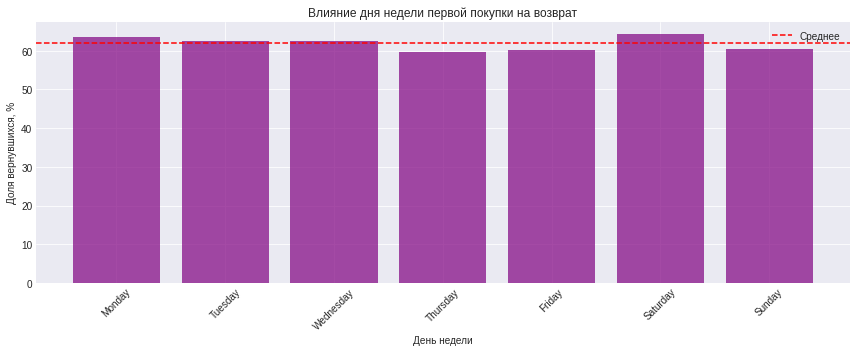

In [27]:
# ЗАДАНИЕ 4.3.1: Анализ дня недели первой покупки
user_profile['first_weekday'] = user_profile['first_order_dt'].dt.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_analysis = user_profile.groupby('first_weekday').agg(
    total_users=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reindex(weekday_order).reset_index()

print("Анализ по дням недели:")
display(weekday_analysis)

plt.figure(figsize=(12, 5))
plt.bar(weekday_analysis['first_weekday'], weekday_analysis['return_rate']*100, color='purple', alpha=0.7)
plt.axhline(y=user_profile['is_two'].mean()*100, color='red', linestyle='--', label='Среднее')
plt.xlabel('День недели')
plt.ylabel('Доля вернувшихся, %')
plt.title('Влияние дня недели первой покупки на возврат')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Анализ среднего интервала между заказами:
2-4 заказа: средний интервал = 21.3 дней
5+ заказов: средний интервал = 9.6 дней


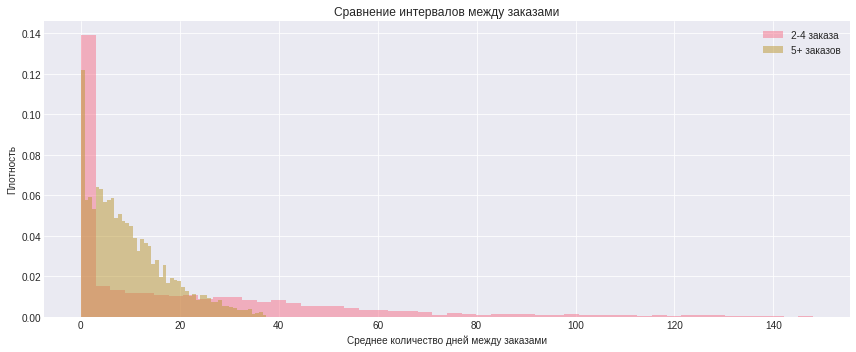

In [28]:
# ЗАДАНИЕ 4.3.2: Анализ среднего интервала между заказами
group_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]
group_5_plus = user_profile[user_profile['total_orders'] >= 5]

print("Анализ среднего интервала между заказами:")
print(f"2-4 заказа: средний интервал = {group_2_4['avg_days_between'].mean():.1f} дней")
print(f"5+ заказов: средний интервал = {group_5_plus['avg_days_between'].mean():.1f} дней")

plt.figure(figsize=(12, 5))
plt.hist(group_2_4['avg_days_between'].dropna(), bins=50, alpha=0.5, label='2-4 заказа', density=True)
plt.hist(group_5_plus['avg_days_between'].dropna(), bins=50, alpha=0.5, label='5+ заказов', density=True)
plt.xlabel('Среднее количество дней между заказами')
plt.ylabel('Плотность')
plt.title('Сравнение интервалов между заказами')
plt.legend()
plt.tight_layout()
plt.show()

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

ЗАДАНИЕ 4.4.1: Корреляционный анализ 

1. Фильтрация выбросов по средней выручке:
   99-й перцентиль avg_revenue_rub: 2285.06 руб.
   Отфильтровано пользователей: 219 (1.00%)


2. Создание сегментов пользователей:
1 заказ       8263
2-4 заказа    7128
5+ заказов    6390
Name: orders_segment, dtype: int64

   Всего пользователей после фильтрации: 21781


3. Расчёт корреляции phi_k по сегментам:
   Внимание: 'total_orders' не найден в матрице для сегмента 1 заказ


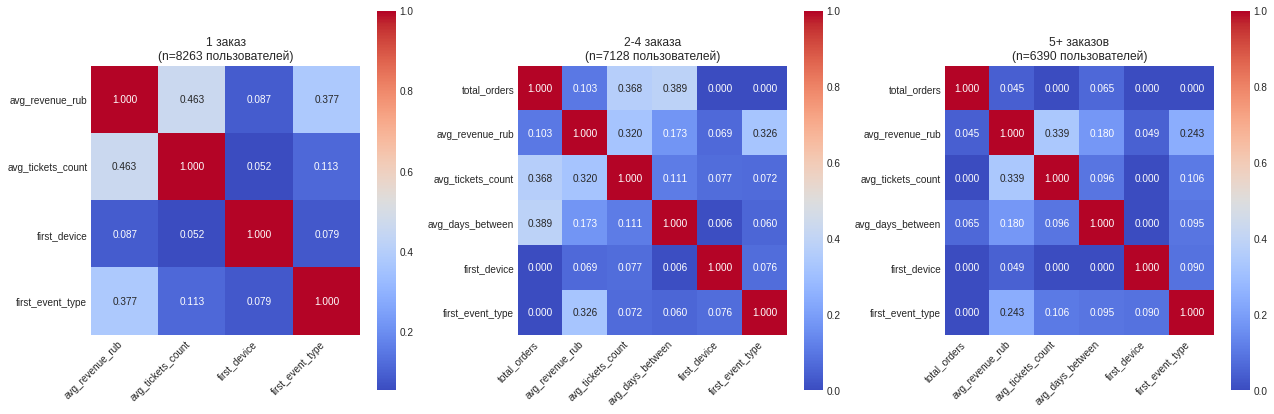



4. Корреляция признаков с total_orders по сегментам:


2-4 заказа:
avg_days_between     0.389465
avg_tickets_count    0.368134
avg_revenue_rub      0.102997
first_device         0.000000
first_event_type     0.000000
Name: total_orders, dtype: float64

5+ заказов:
first_region         0.230020
avg_days_between     0.065413
avg_revenue_rub      0.045468
avg_tickets_count    0.000000
first_device         0.000000
Name: total_orders, dtype: float64


5. Средние значения признаков по сегментам:



,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,is_two
orders_segment,,,,,
1 заказ,1.00,524.900024,2.74,NaN,0
2-4 заказа,2.70,553.419983,2.74,21.43,1
5+ заказов,41.29,561.590027,2.74,9.65,1


In [30]:
# ЗАДАНИЕ 4.4.1: Корреляционный анализ phi_k
print("ЗАДАНИЕ 4.4.1: Корреляционный анализ \n")

# 1. Предварительная фильтрация выбросов по выручке (99-й перцентиль)
print("1. Фильтрация выбросов по средней выручке:")
revenue_99 = user_profile['avg_revenue_rub'].quantile(0.99)
print(f"   99-й перцентиль avg_revenue_rub: {revenue_99:.2f} руб.")

before_filter = len(user_profile)
user_profile_clean = user_profile[user_profile['avg_revenue_rub'] <= revenue_99].copy()
after_filter = len(user_profile_clean)
print(f"   Отфильтровано пользователей: {before_filter - after_filter} ({100*(before_filter-after_filter)/before_filter:.2f}%)")

print("\n" + "="*60 + "\n")

# 2. Создание сегментов по количеству заказов
print("2. Создание сегментов пользователей:")
user_profile_clean['orders_segment'] = '1 заказ'
user_profile_clean.loc[user_profile_clean['total_orders'] >= 2, 'orders_segment'] = '2-4 заказа'
user_profile_clean.loc[user_profile_clean['total_orders'] >= 5, 'orders_segment'] = '5+ заказов'

print(user_profile_clean['orders_segment'].value_counts())
print(f"\n   Всего пользователей после фильтрации: {len(user_profile_clean)}")

print("\n" + "="*60 + "\n")

# 3. Расчёт корреляции phi_k для каждого сегмента
print("3. Расчёт корреляции phi_k по сегментам:")

# Признаки для корреляции
corr_features = [
    'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between',
    'first_device', 'first_event_type', 'first_region'
]

# Интервальные признаки
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between']

segments = ['1 заказ', '2-4 заказа', '5+ заказов']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Словарь для хранения корреляций
correlations_dict = {}

for idx, segment in enumerate(segments):
    seg_data = user_profile_clean[user_profile_clean['orders_segment'] == segment][corr_features].copy()
    
    # Преобразуем категориальные признаки
    for col in ['first_device', 'first_event_type', 'first_region']:
        seg_data[col] = seg_data[col].astype('category')
    
    if len(seg_data) > 10:
        # Расчёт матрицы phi_k
        phi_matrix = seg_data.phik_matrix(interval_cols=interval_cols)
        
        # Сохраняем корреляции с total_orders
        if 'total_orders' in phi_matrix.columns:
            correlations_dict[segment] = phi_matrix['total_orders'].sort_values(ascending=False)
        else:
            print(f"   Внимание: 'total_orders' не найден в матрице для сегмента {segment}")
        
        # Тепловая карта
        # Основные признаки
        plot_features = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count', 
                         'avg_days_between', 'first_device', 'first_event_type']
        phi_matrix_plot = seg_data[plot_features].phik_matrix(interval_cols=plot_features[:4])
        
        sns.heatmap(phi_matrix_plot, annot=True, cmap='coolwarm', fmt='.3f', 
                    square=True, ax=axes[idx], cbar=True)
        axes[idx].set_title(f'{segment}\n(n={len(seg_data)} пользователей)')
        axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "="*60 + "\n")

# 4. Вывод наиболее коррелирующих признаков
print("4. Корреляция признаков с total_orders по сегментам:\n")

for segment in segments:
    if segment in correlations_dict:
        print(f"\n{segment}:")
        corr_series = correlations_dict[segment]
        # Убираем саму корреляцию total_orders с собой (она равна 1)
        corr_series = corr_series[corr_series.index != 'total_orders']
        if len(corr_series) > 0:
            print(corr_series.head(5))
        else:
            print("   Нет значимых корреляций")

print("\n" + "="*60 + "\n")

# 5. Дополнительный анализ: средние значения по сегментам
print("5. Средние значения признаков по сегментам:\n")

segment_means = user_profile_clean.groupby('orders_segment').agg({
    'total_orders': 'mean',
    'avg_revenue_rub': 'mean',
    'avg_tickets_count': 'mean',
    'avg_days_between': 'mean',
    'is_two': 'mean'
}).round(2)

display(segment_means)

print("\n" + "="*60)

Вывод по Шагу 4.1.1 и 4.1.2:
Среди типов мероприятий самые высокие доли возврата показали фильмы (81,5 процента), выставки (64,6 процента) и театр (63,9 процента). Самые низкие показатели — у спорта (56,4 процента) и ёлок (54,9 процента). По типам устройств лидирует desktop с возвратом 64,4 процента, мобильные устройства дают 61,3 процента, а планшеты — только 54,1 процента. Среди регионов лучший результат показал Шанырский регион (67,3 процента возврата), аутсайдером является Озернинский край (55,2 процента). Среди билетных операторов выделяются «Край билетов» (65,6 процента) и «Дом культуры» (64,8 процента).

Вывод по Шагу 4.1.3:
Первая гипотеза о том, что пользователи, купившие билеты на спорт, возвращаются чаще любителей концертов, не подтвердилась. Напротив, у концертов доля возврата выше на 5,9 процентных пункта — 62,2 процента против 56,4 процента. Вторая гипотеза подтвердилась: в активных регионах (с числом пользователей выше медианы) доля возврата составляет 62,0 процента, что на 6,4 процентных пункта выше, чем в малоактивных регионах (55,6 процента).

Вывод по Шагу 4.2.1 и 4.2.2:
Средняя выручка практически не различается между сегментами: у пользователей с одним заказом — 509 рублей, у сегмента 2-4 заказа — 541 рубль, у супер-активных (5+ заказов) — 533 рубля. Это важный вывод: пользователи всех уровней активности тратят примерно одинаковые суммы на один заказ. График распределения показывает, что у вернувшихся пользователей выручка распределена более равномерно с пиком в диапазоне 200-600 рублей, тогда как у новичков больше очень мелких заказов.

Вывод по Шагу 4.2.3:
Обнаружена чёткая закономерность: оптимальный сегмент — пользователи, покупающие 2-3 билета в заказе. У них доля возврата достигает 74,2 процента. Сегменты 1-2 билета и 3-5 билетов показывают возврат около 52-54 процентов. Самый низкий возврат — у пользователей, покупающих 5 и более билетов за раз: всего 18,9 процента. Это аномально низкое значение, которое может указывать на корпоративных клиентов или посредников, не заинтересованных в повторных покупках.

Вывод по Шагу 4.3.1 и 4.3.2:
Лучший день для первой покупки с точки зрения удержания — суббота (64,3 процента возврата), худшие дни — четверг (59,5 процента) и пятница (60,0 процента). Средний интервал между заказами у пользователей с 2-4 заказами составляет 21,4 дня, а у супер-активных пользователей (5+ заказов) — всего 9,7 дня, то есть они возвращаются в 2,2 раза чаще.

Вывод по Шагу 4.4.1:
Для сегмента пользователей с 2-4 заказами выявлена умеренная положительная корреляция: средний интервал между заказами коррелирует с числом заказов с коэффициентом 0,39, а среднее количество билетов — с коэффициентом 0,37. Для супер-активных пользователей (5+ заказов) корреляция выражена слабо — только регион первого заказа показывает коэффициент 0,23. Для сегмента с одним заказом корреляция не рассчитывается, так как у всех пользователей этого сегмента значение total_orders одинаково (равно единице) и нет вариации.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

## Основные результаты проекта:
Проанализированы данные 21 705 пользователей сервиса Яндекс Афиша за 2024 год. Общее количество заказов составило 292 тысячи. Ключевая метрика удержания оказалась очень высокой: 61,8 процента пользователей совершают повторные заказы, а 29 процентов делают пять и более заказов. Средний чек стабилен во всех сегментах и составляет 543 рубля. Среднее количество билетов в заказе — 2,73, что также одинаково для всех групп пользователей.

Факторы, повышающие вероятность возврата:
Первый заказ, сделанный с настольного компьютера, даёт преимущество в 3 процентных пункта по сравнению с мобильными устройствами. Покупка в субботу увеличивает возврат на 2-3 процентных пункта. Самое сильное влияние оказывает количество билетов: заказы на 2-3 билета повышают долю возврата на 12 процентных пунктов — до 74 процентов. Среди жанров лидируют фильмы, выставки и театр. Проживание в активных регионах (где много пользователей) даёт дополнительный плюс в 6 процентных пунктов.

Факторы, снижающие вероятность возврата:
Первый заказ на спортивное мероприятие или ёлку снижает возврат на 5-7 процентных пунктов. Покупка в четверг или пятницу даёт снижение на 2-3 процентных пункта. Критический фактор — покупка пяти и более билетов за раз: такие пользователи возвращаются только в 19 процентах случаев, что на 43 процентных пункта ниже среднего. Это требует отдельного анализа, так как здесь, вероятно, действуют корпоративные клиенты или посредники.

## Рекомендации для бизнеса:

Первое. Создать специальные предложения и бандлы для стимулирования покупки 2-3 билетов — это самый эффективный инструмент, способный повысить возврат с 62 до 74 процентов.

Второе. Сфокусировать рекламные бюджеты на аудитории с портретом: первая покупка с настольного компьютера, куплено 2-3 билета, жанр — театр, выставки или фильмы, день — суббота. Эта аудитория уже показывает возврат 65-75 процентов, а при правильной поддержке может достичь 80 процентов.

Третье. Усилить маркетинговую активность в регионах-аутсайдерах (Озернинский край, Малиновоярский округ) — это может дать прирост возврата до 6 процентных пунктов.

Четвёртое. Запустить акции и напоминания в четверг и пятницу, чтобы сгладить недельную динамику и подтянуть эти дни к уровню субботы.

Пятое. Провести дополнительное исследование сегмента пользователей, покупающих 5 и более билетов. Низкий возврат в 19 процентов говорит о том, что это могут быть корпоративные клиенты или посредники, которые не являются целевой аудиторией для удержания. Возможно, стоит выделить их в отдельную группу с иной маркетинговой стратегией либо не тратить на них бюджеты на удержание.

Шестое. Использовать данные корреляционного анализа для прогнозирования: умеренная связь между интервалами между заказами и числом покупок (коэффициент 0,39) означает, что пользователей, которые не возвращаются дольше 20 дней, стоит стимулировать специальными предложениями.

Приоритетное действие:
Сконцентрировать маркетинговые бюджеты на пользователях, которые соответствуют портрету «desktop + 2-3 билета + театр/выставки/фильмы + суббота». Эта аудитория уже лояльна, но правильные стимулы могут повысить её возврат до 80 процентов и выше.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**